In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from statsmodels.tsa.seasonal import seasonal_decompose
from prophet import Prophet
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [3]:
# Контрольная работа:
# Датасет "Демографические показатели смертности в регионах России с 1989 года"
# https://tochno.st/datasets/mortality
# Показатель: "Ожидаемая продолжительность жизни" (ОПЖ)
# Нужно посмотреть: Оба пола, Возраст 0 лет, Регион Республика Саха (Якутия)
# Задачи:
# 1. Загрузить нужный датасет
# 2. Оставить только нужные строки (фильтрация по региону, возрасту и полу) и нужные столбцы (Год, Значение).
# 3. Построить график ОПЖ в РС(Я)
# 4. Расчитайте столбец с изменения год от года. 
# 5. Добавьте столбец статуса с категориями 'Падение', 'Без изменений', 'Рост'.
# 6. Какое было наибольшнее падение ОПЖ и в каком году
# 7. Сделайте прогнозную модель ОПЖ, для теста используйте последние 5 лет

In [4]:
df_raw = pd.read_csv('../data/raw/data_mortality_142_v20241125_csv/ex.csv', delimiter=';')

In [5]:
df_raw

,indicator_name,indicator_unit,indicator_code,sex,age,object_name,object_level,object_oktmo,object_okato,year,indicator_value
0,Ожидаемая продолжительность жизни,лет,Y477000003,Оба пола,0,Российская Федерация,страна,0,0,1989,69.6
1,Ожидаемая продолжительность жизни,лет,Y477000003,Оба пола,15,Российская Федерация,страна,0,0,1989,56.4
2,Ожидаемая продолжительность жизни,лет,Y477000003,Оба пола,50,Российская Федерация,страна,0,0,1989,25.4
3,Ожидаемая продолжительность жизни,лет,Y477000003,Оба пола,65,Российская Федерация,страна,0,0,1989,14.8
4,Ожидаемая продолжительность жизни,лет,Y477000003,Мужчины,0,Российская Федерация,страна,0,0,1989,64.2
...,...,...,...,...,...,...,...,...,...,...,...
33787,Ожидаемая продолжительность жизни,лет,Y477000003,Мужчины,65,Сахалинская область,регион,64000000,64000000,2023,14.7
33788,Ожидаемая продолжительность жизни,лет,Y477000003,Женщины,0,Сахалинская область,регион,64000000,64000000,2023,77.5
33789,Ожидаемая продолжительность жизни,лет,Y477000003,Женщины,15,Сахалинская область,регион,64000000,64000000,2023,62.8
33790,Ожидаемая продолжительность жизни,лет,Y477000003,Женщины,50,Сахалинская область,регион,64000000,64000000,2023,30.3


In [6]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33792 entries, 0 to 33791
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   indicator_name   33792 non-null  object 
 1   indicator_unit   33792 non-null  object 
 2   indicator_code   33792 non-null  object 
 3   sex              33792 non-null  object 
 4   age              33792 non-null  int64  
 5   object_name      33792 non-null  object 
 6   object_level     33792 non-null  object 
 7   object_oktmo     33792 non-null  int64  
 8   object_okato     33792 non-null  int64  
 9   year             33792 non-null  int64  
 10  indicator_value  33792 non-null  float64
dtypes: float64(1), int64(4), object(6)
memory usage: 2.8+ MB


In [7]:
df = df_raw[(df_raw['sex']=='Оба пола') & (df_raw['object_name']=='Республика Саха (Якутия)') & (df_raw['age']==0)].sort_values('year').reset_index()[['year', 'indicator_value']].copy()
df = df.rename(columns={'indicator_value':'life_expectancy'})

In [8]:
df.head(5)

,year,life_expectancy
0,1989,67.5
1,1990,66.3
2,1991,66.4
3,1992,64.5
4,1993,63.4


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   year             35 non-null     int64  
 1   life_expectancy  35 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 692.0 bytes


In [10]:
df_down = df.copy()
df_down['previous_year_life_expectancy'] = df_down['life_expectancy'].shift(1)
df_down['year_diff_life_expectancy'] = df_down['life_expectancy'] - df_down['previous_year_life_expectancy']

In [11]:
# Список условий
conditions = [
    df_down['year_diff_life_expectancy'] > 0,
    df_down['year_diff_life_expectancy'] == 0,
    df_down['year_diff_life_expectancy'] < 0,
]

# Список соответствующих значений
choices = [
    'Рост',
    'Без изменений',
    'Падение',
]

df_down['year_diff_status'] = np.select(conditions, choices, default='Нет данных')

In [12]:
df_down

,year,life_expectancy,previous_year_life_expectancy,year_diff_life_expectancy,year_diff_status
0,1989,67.5,NaN,NaN,Нет данных
1,1990,66.3,67.5,-1.2,Падение
2,1991,66.4,66.3,0.1,Рост
3,1992,64.5,66.4,-1.9,Падение
4,1993,63.4,64.5,-1.1,Падение
5,1994,61.9,63.4,-1.5,Падение
6,1995,62.3,61.9,0.4,Рост
7,1996,63.1,62.3,0.8,Рост
8,1997,64.1,63.1,1.0,Рост
9,1998,64.3,64.1,0.2,Рост


In [13]:
max_down = np.min(df_down['year_diff_life_expectancy'])
print(f'Максимальное падение продолжительности жизни: {abs(max_down):.2f}')
print(f'Года с максимальным падением: {df_down[(df_down['year_diff_life_expectancy'].shift(1))==max_down]['year'].to_list()}')

Максимальное падение продолжительности жизни: 1.90
Года с максимальным падением: [1993, 2021]


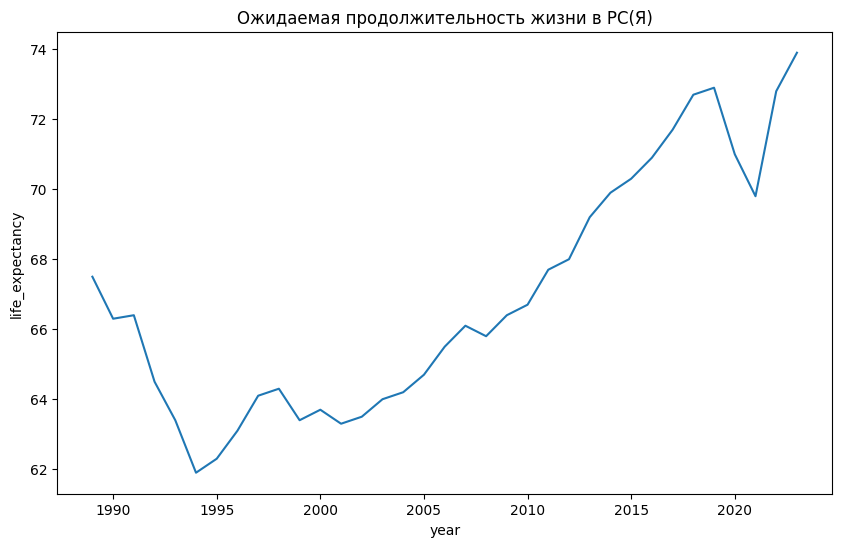

In [14]:
plt.figure(figsize=(10, 6))
plt.title('Ожидаемая продолжительность жизни в РС(Я)')
sns.lineplot(data=df, x='year', y='life_expectancy') # hue снова добавляет 3-е измерение!
plt.show()

In [15]:
df_features = df.copy()

In [16]:
# 2. Лаги (Lag features). Смотрим на 1, 2, 3, 4 года назад
for i in range(1, 5):
    df_features[f'lag_{i}'] = df_features['life_expectancy'].shift(i)

In [17]:
# 3. Скользящее среднее (например, за полгода)
# shift(1) важен! Мы не можем знать среднее за текущий год, прогнозируя год.
df_features['rolling_mean_5'] = df_features['life_expectancy'].shift(1).rolling(5).mean()

In [18]:
df_features.head(6)

,year,life_expectancy,lag_1,lag_2,lag_3,lag_4,rolling_mean_5
0,1989,67.5,NaN,NaN,NaN,NaN,NaN
1,1990,66.3,67.5,NaN,NaN,NaN,NaN
2,1991,66.4,66.3,67.5,NaN,NaN,NaN
3,1992,64.5,66.4,66.3,67.5,NaN,NaN
4,1993,63.4,64.5,66.4,66.3,67.5,NaN
5,1994,61.9,63.4,64.5,66.4,66.3,65.62


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   year             35 non-null     int64  
 1   life_expectancy  35 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 692.0 bytes


In [20]:
df_features = df_features.dropna()

In [21]:
df_features.head(6)

,year,life_expectancy,lag_1,lag_2,lag_3,lag_4,rolling_mean_5
5,1994,61.9,63.4,64.5,66.4,66.3,65.62
6,1995,62.3,61.9,63.4,64.5,66.4,64.50
7,1996,63.1,62.3,61.9,63.4,64.5,63.70
8,1997,64.1,63.1,62.3,61.9,63.4,63.04
9,1998,64.3,64.1,63.1,62.3,61.9,62.96
10,1999,63.4,64.3,64.1,63.1,62.3,63.14


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   year             35 non-null     int64  
 1   life_expectancy  35 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 692.0 bytes


In [23]:
test_size = 5
train = df_features.iloc[:-test_size]
test = df_features.iloc[-test_size:]

In [24]:
train

,year,life_expectancy,lag_1,lag_2,lag_3,lag_4,rolling_mean_5
5,1994,61.9,63.4,64.5,66.4,66.3,65.62
6,1995,62.3,61.9,63.4,64.5,66.4,64.50
7,1996,63.1,62.3,61.9,63.4,64.5,63.70
8,1997,64.1,63.1,62.3,61.9,63.4,63.04
9,1998,64.3,64.1,63.1,62.3,61.9,62.96
10,1999,63.4,64.3,64.1,63.1,62.3,63.14
11,2000,63.7,63.4,64.3,64.1,63.1,63.44
12,2001,63.3,63.7,63.4,64.3,64.1,63.72
13,2002,63.5,63.3,63.7,63.4,64.3,63.76
14,2003,64.0,63.5,63.3,63.7,63.4,63.64


In [25]:
test

,year,life_expectancy,lag_1,lag_2,lag_3,lag_4,rolling_mean_5
30,2019,72.9,72.7,71.7,70.9,70.3,71.10
31,2020,71.0,72.9,72.7,71.7,70.9,71.70
32,2021,69.8,71.0,72.9,72.7,71.7,71.84
33,2022,72.8,69.8,71.0,72.9,72.7,71.62
34,2023,73.9,72.8,69.8,71.0,72.9,71.84


In [26]:
# Формируем X и y
X_train = train.drop('life_expectancy', axis=1)
y_train = train['life_expectancy']

X_test = test.drop('life_expectancy', axis=1)
y_test = test['life_expectancy']

In [27]:
# Обучение
model = LinearRegression()
model.fit(X_train, y_train)

# Прогноз
preds = model.predict(X_test)

# Оценка (Метрика MAE - средняя ошибка в пассажирах)
mae = mean_absolute_error(y_test, preds)
print(f'MAE: {mae:.2f}') # Например: ошибаемся в среднем на 20-30 человек

MAE: 1.63


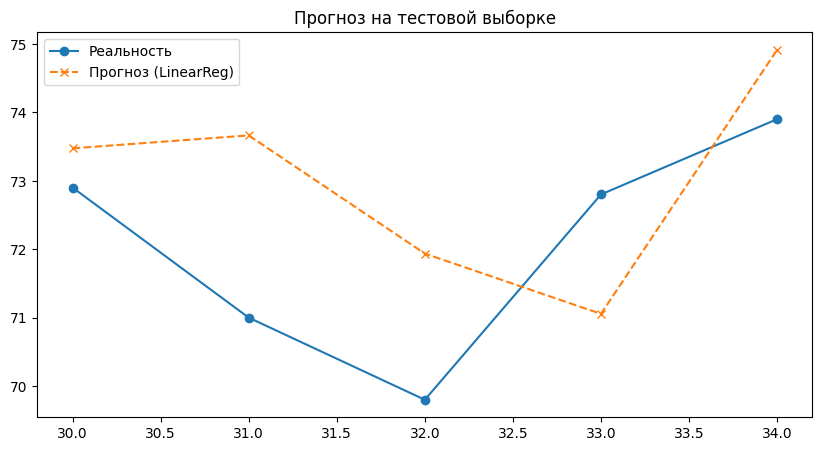

In [28]:
# Визуализация: Факт vs Прогноз
plt.figure(figsize=(10, 5))
plt.plot(test.index, y_test, label='Реальность', marker='o')
plt.plot(test.index, preds, label='Прогноз (LinearReg)', marker='x', linestyle='--')
plt.legend()
plt.title('Прогноз на тестовой выборке')
plt.show()